# Learning Rate Sweep (B3)

Test `[1e-4, 1e-3, 1e-2, 1e-1, 1.0]` with Adam to find the sweet spot.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from network import Network, NetworkConfig
from optimizer import Adam

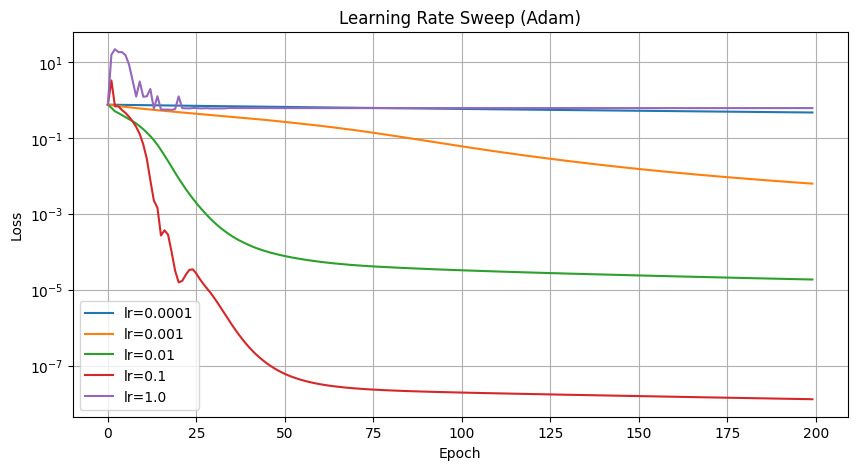

Final losses:
  lr=0.0001   -> 0.476922
  lr=0.001    -> 0.006353
  lr=0.01     -> 0.000019
  lr=0.1      -> 0.000000
  lr=1.0      -> 0.623610

Best: 0.1


In [2]:
np.random.seed(42)
x = np.random.randn(50, 30)
y = np.zeros((50, 2))
y[np.arange(50), np.random.randint(0, 2, 50)] = 1

lrs = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
plt.figure(figsize=(10, 5))
results = {}

for lr in lrs:
    np.random.seed(42)
    net = Network(NetworkConfig(layers=[30, 24, 24, 24, 2], activation='relu',
        loss='cross_entropy', output_activation='softmax', weights_initializer='heUniform'))
    opt = Adam(learning_rate=lr)
    losses = []
    for _ in range(200):
        out = net.forward(x)
        loss = net.loss(y, out)
        if np.isnan(loss) or np.isinf(loss):
            losses.append(float('nan')); break
        losses.append(loss)
        nw, nb = net.backward(y)
        opt.update(net, nw, nb)
    results[lr] = losses[-1]
    plt.plot(losses, label=f'lr={lr}')

plt.title('Learning Rate Sweep (Adam)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.yscale('log'); plt.legend(); plt.grid(True); plt.show()

print('Final losses:')
for lr, l in results.items():
    print(f'  lr={lr:<8} -> {l:.6f}')
print(f'\nBest: {min(results, key=results.get)}')